Weather data retrieved successfully!

Raw Weather Data:
              datetime  temperature  humidity  wind_speed  precipitation
0  2026-08-20 06:00:00        27.86        55        7.15            0.0
1  2026-08-20 09:00:00        28.08        57        8.12            0.0
2  2026-08-20 12:00:00        27.27        67        6.79            0.0
3  2026-08-20 15:00:00        24.73        84        4.16            0.0
4  2026-08-20 18:00:00        24.40        87        3.86            0.0

Missing values:
datetime         0
temperature      0
humidity         0
wind_speed       0
precipitation    0
date             0
dtype: int64

Weather Statistics:
Average Temperature: 24.485
Maximum Temperature: 28.08
Minimum Temperature: 22.13
Average Humidity: 79.675
Average Wind Speed: 4.98625
Total Precipitation: 1.4100000000000001


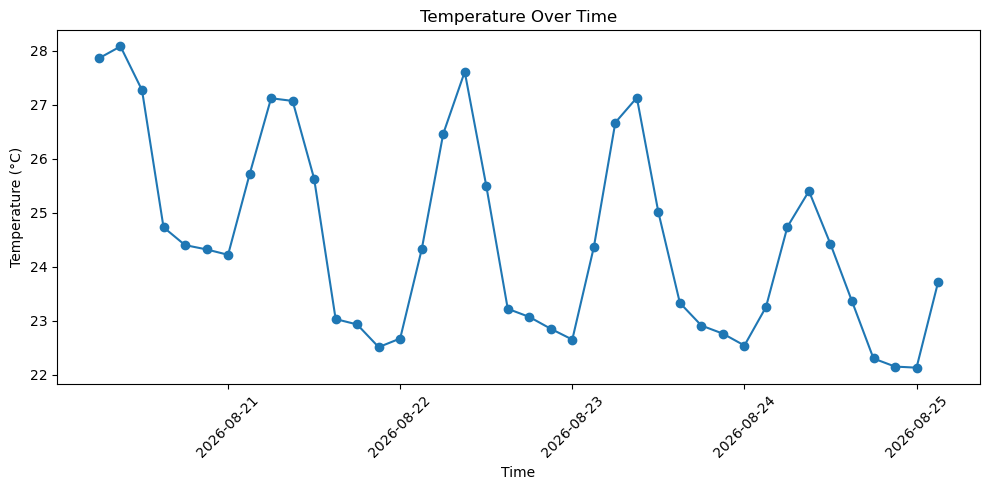

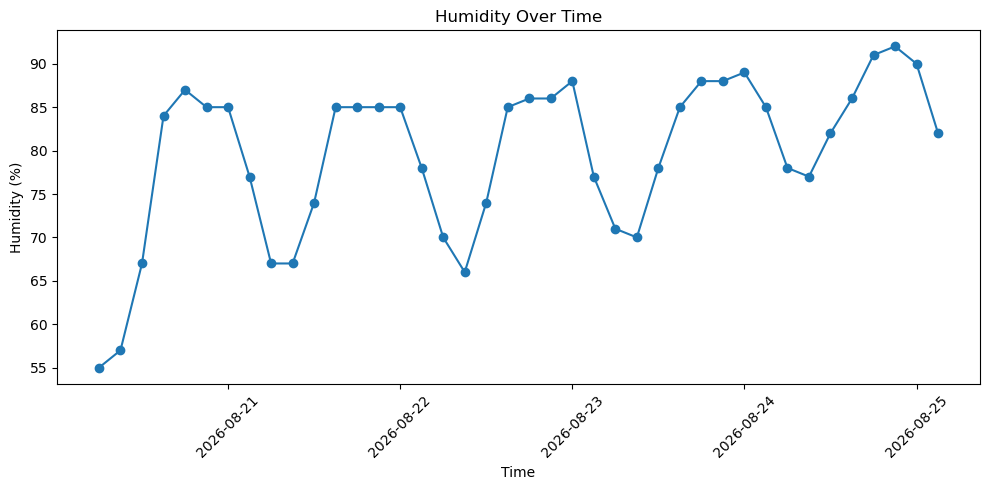

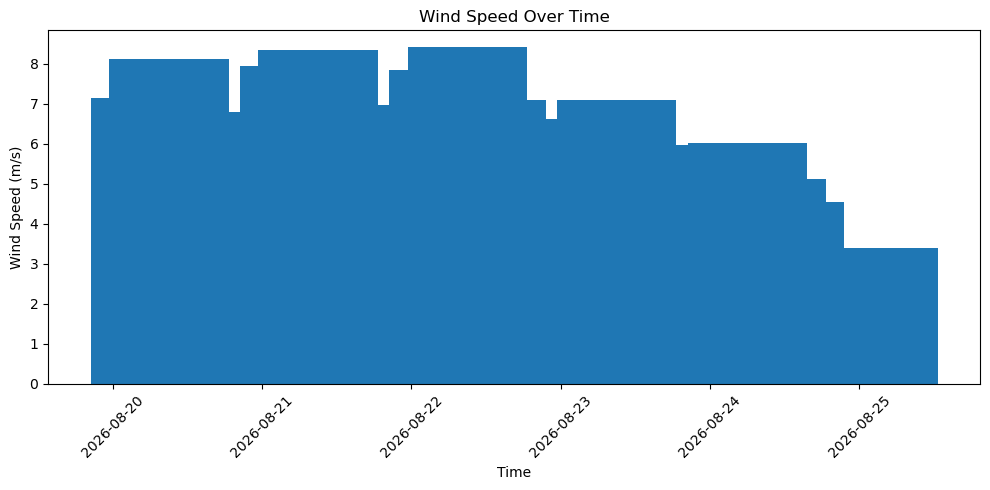

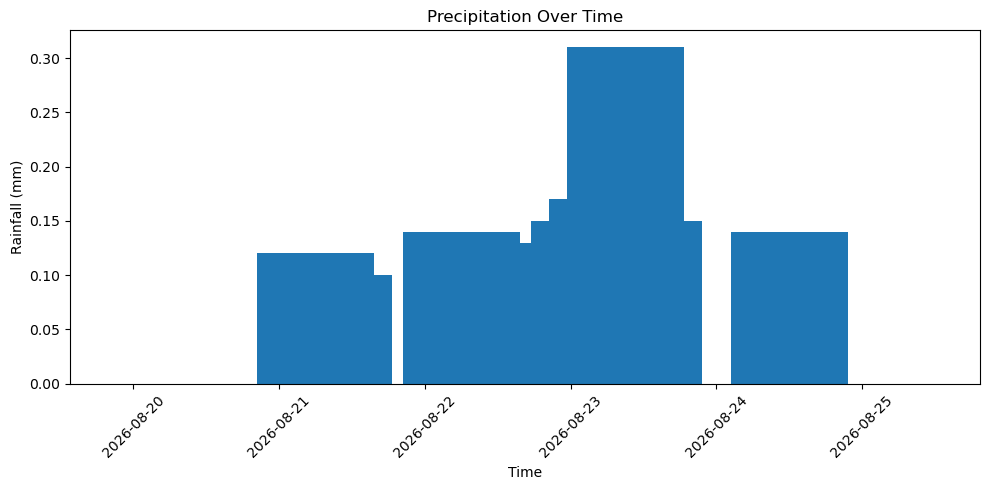


Daily Weather Summary:
           temperature               humidity wind_speed precipitation
                  mean    min    max     mean       mean           sum
date                                                                  
2026-08-20     26.1100  24.32  28.08   72.500    5.67500          0.00
2026-08-21     24.7775  22.51  27.12   78.125    5.62625          0.22
2026-08-22     24.4625  22.67  27.61   78.750    5.55375          0.27
2026-08-23     24.3525  22.65  27.13   80.625    4.86250          0.78
2026-08-24     23.5200  22.15  25.40   85.000    3.86750          0.14
2026-08-25     22.9200  22.13  23.71   86.000    3.06000          0.00

Map saved as weather_map.html

Correlation Matrix:
               temperature  humidity  wind_speed  precipitation
temperature       1.000000 -0.951276    0.920093       0.439873
humidity         -0.951276  1.000000   -0.923961      -0.376754
wind_speed        0.920093 -0.923961    1.000000       0.483974
precipitation     0.439873 -0

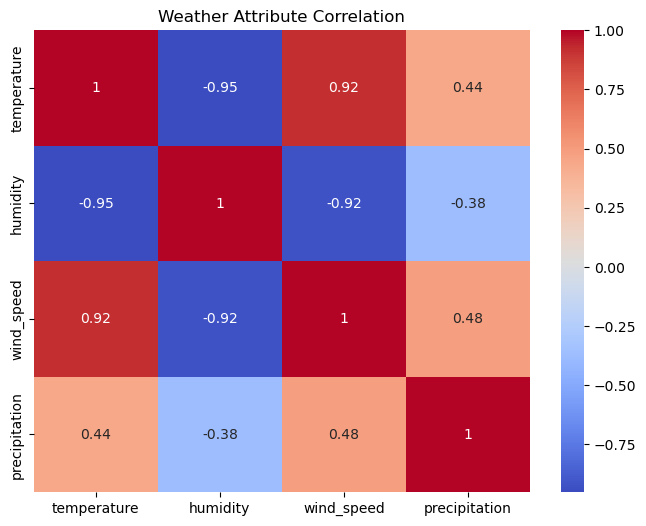

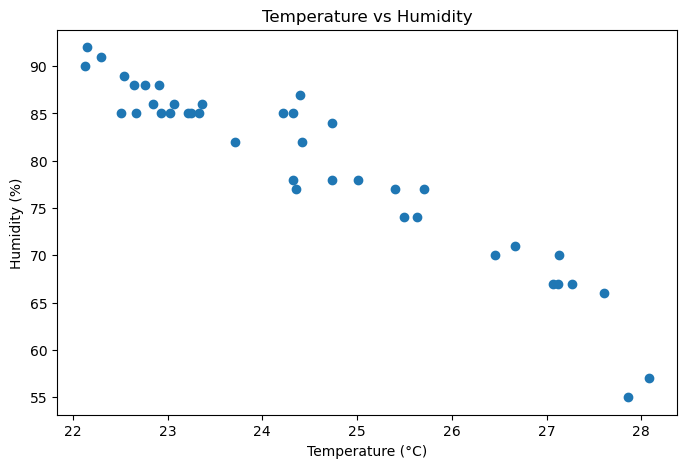

In [15]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from dotenv import load_dotenv

# -----------------------------
# 1. Load API key
# -----------------------------
load_dotenv()

API_KEY = os.getenv("OPENWEATHER_API_KEY")

# -----------------------------
# 2. Get weather data
# -----------------------------
city = "Pune"

url = "https://api.openweathermap.org/data/2.5/forecast"

params = {
    "q": city,
    "appid": API_KEY,
    "units": "metric"
}

response = requests.get(url, params=params)
data = response.json()

# Check API response
if response.status_code != 200:
    print("Error:", data)
    exit()

print("Weather data retrieved successfully!")

# -----------------------------
# 3. Extract relevant data
# -----------------------------
weather = []

for item in data["list"]:
    weather.append({
        "datetime": item["dt_txt"],
        "temperature": item["main"]["temp"],
        "humidity": item["main"]["humidity"],
        "wind_speed": item["wind"]["speed"],
        "precipitation": item.get("rain", {}).get("3h", 0)
    })

df = pd.DataFrame(weather)

print("\nRaw Weather Data:")
print(df.head())

# -----------------------------
# 4. Clean and preprocess
# -----------------------------
df["datetime"] = pd.to_datetime(df["datetime"])

df = df.dropna()

df["date"] = df["datetime"].dt.date

print("\nMissing values:")
print(df.isnull().sum())

# -----------------------------
# 5. Data modeling
# -----------------------------

print("\nWeather Statistics:")

print("Average Temperature:",
      df["temperature"].mean())

print("Maximum Temperature:",
      df["temperature"].max())

print("Minimum Temperature:",
      df["temperature"].min())

print("Average Humidity:",
      df["humidity"].mean())

print("Average Wind Speed:",
      df["wind_speed"].mean())

print("Total Precipitation:",
      df["precipitation"].sum())

# -----------------------------
# 6. Visualizations
# -----------------------------

# Temperature over time
plt.figure(figsize=(10, 5))
plt.plot(df["datetime"], df["temperature"], marker="o")
plt.title("Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Humidity over time
plt.figure(figsize=(10, 5))
plt.plot(df["datetime"], df["humidity"], marker="o")
plt.title("Humidity Over Time")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Wind speed
plt.figure(figsize=(10, 5))
plt.bar(df["datetime"], df["wind_speed"])
plt.title("Wind Speed Over Time")
plt.xlabel("Time")
plt.ylabel("Wind Speed (m/s)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Precipitation
plt.figure(figsize=(10, 5))
plt.bar(df["datetime"], df["precipitation"])
plt.title("Precipitation Over Time")
plt.xlabel("Time")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# 7. Daily aggregation
# -----------------------------

daily = df.groupby("date").agg({
    "temperature": ["mean", "min", "max"],
    "humidity": "mean",
    "wind_speed": "mean",
    "precipitation": "sum"
})

print("\nDaily Weather Summary:")
print(daily)

# -----------------------------
# 8. Geographical visualization
# -----------------------------

latitude = data["city"]["coord"]["lat"]
longitude = data["city"]["coord"]["lon"]

weather_map = folium.Map(
    location=[latitude, longitude],
    zoom_start=10
)

folium.Marker(
    [latitude, longitude],
    popup=f"{city} Weather"
).add_to(weather_map)

weather_map.save("weather_map.html")

print("\nMap saved as weather_map.html")

# -----------------------------
# 9. Correlation analysis
# -----------------------------

correlation = df[
    ["temperature", "humidity", "wind_speed", "precipitation"]
].corr()

print("\nCorrelation Matrix:")
print(correlation)

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Weather Attribute Correlation")
plt.show()

# Temperature vs Humidity
plt.figure(figsize=(8, 5))
plt.scatter(df["temperature"], df["humidity"])
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.show()